# Report 1 - Reproducible Analysis (Freight Rate Volatility: Air vs Road, EU)
Six states (DE, IT, ES, NL, PL, FR). Eurostat SPPI for air (H51) and road (H494); French air from INSEE (CPF 51.21), because Eurostat carries no French air series. Re-running this cell reproduces the six-state figures and statistics from the local data files.

France air in Eurostat (PRC_PRR/I21/NSA): 0 non-null  ->  French air taken from INSEE series 010766683 (CPF 51.21) instead
rows: 696 | geos: ['DE', 'ES', 'FR', 'IT', 'NL', 'PL']

Coefficient of variation by country (std/mean of level):
mode    air   road
geo               
DE    0.148  0.099
IT    0.282  0.053
ES    0.108  0.079
NL    0.086  0.099
PL    0.120  0.167
FR    0.186  0.074
mean: air 0.155  road 0.095  ratio 1.63

Levene (air vs road QoQ changes): stat 65.0  p 3.31e-15  | air std 0.053 vs road std 0.016
Kruskal-Wallis air  stat  49.6  p 9.91e-11  mean QoQ% by quarter {1: np.float64(-0.97), 2: np.float64(3.2), 3: np.float64(1.49), 4: np.float64(-0.78)}
Kruskal-Wallis road stat  17.6  p 5.41e-04  mean QoQ% by quarter {1: np.float64(0.27), 2: np.float64(0.99), 3: np.float64(0.95), 4: np.float64(0.23)}


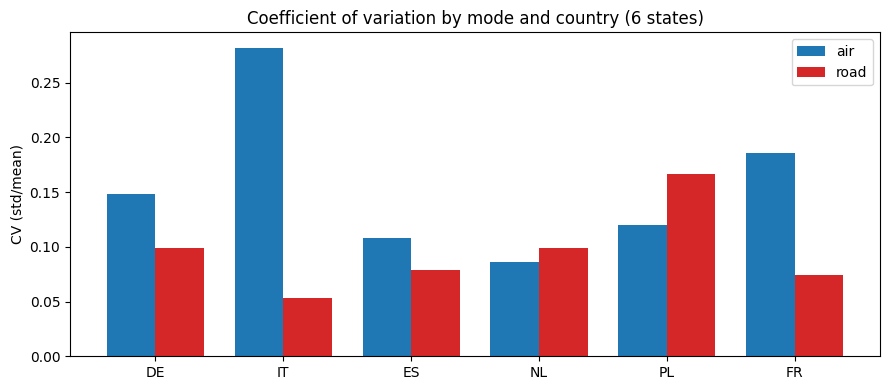

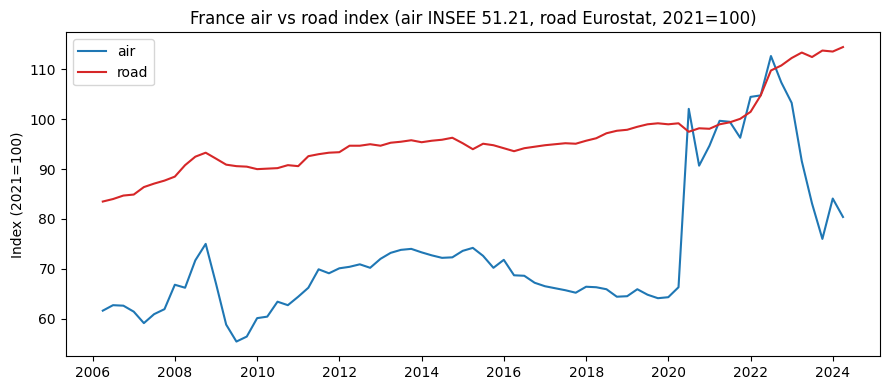

In [1]:

# Report 1 - reproducible SIX-STATE analysis: Freight Rate Volatility, Air vs Road (EU)
# Loads local SPPI data: Eurostat air (H51) + road (H494), and INSEE French air freight (CPF 51.21).
import pandas as pd, numpy as np
from scipy import stats
import matplotlib.pyplot as plt

DATA = "/sessions/zen-vibrant-ritchie/mnt/Claude Application Files/Liora Project/Freight_Project_Workspace/Report_1_Groundwork/data"
GEOS = ["DE","IT","ES","NL","PL","FR"]; CUT = pd.Timestamp(2024,3,31)

def qend(s):
    y,q = s.split("-Q"); return pd.Timestamp(int(y), int(q)*3, 1) + pd.offsets.MonthEnd(0)
def load(p):
    raw = pd.read_csv(p)
    f = raw[(raw.indic_bt=="PRC_PRR") & (raw.unit=="I21") & (raw.s_adj=="NSA")].copy()
    f["date"] = f.TIME_PERIOD.map(qend); return f

air  = load(DATA + "/Eurostat_Air_Transport_Price_Index_SPPI.csv")
road = load(DATA + "/Eurostat_Road_Freight_Price_Index_SPPI.csv")
fr   = pd.read_csv(DATA + "/FR_air_freight_INSEE_010766683.csv", comment="#"); fr["date"] = pd.to_datetime(fr.date)

print("France air in Eurostat (PRC_PRR/I21/NSA):", int(air[air.geo=="FR"].OBS_VALUE.notna().sum()),
      "non-null  ->  French air taken from INSEE series 010766683 (CPF 51.21) instead")

def tidy(f, m):
    t = f[f.geo.isin(GEOS)].dropna(subset=["OBS_VALUE"]).copy(); t["mode"] = m
    return t[["date","geo","mode","OBS_VALUE"]].rename(columns={"OBS_VALUE":"value"})
ta = pd.concat([tidy(air,"air"), fr[["date","geo","mode","value"]]], ignore_index=True)
tr = tidy(road,"road")

rows = []
for g in GEOS:
    a, r = ta[ta.geo==g], tr[tr.geo==g]
    if a.empty or r.empty: continue
    s = max(a.date.min(), r.date.min()); e = min(a.date.max(), r.date.max(), CUT)
    for t in (a, r): rows.append(t[(t.date>=s) & (t.date<=e)])
comp = pd.concat(rows, ignore_index=True).sort_values(["mode","geo","date"])
comp["pct_qoq"] = comp.groupby(["mode","geo"])["value"].transform(lambda s: s.pct_change())
comp["quarter"] = comp.date.dt.quarter
print("rows:", len(comp), "| geos:", sorted(comp.geo.unique()))

cv = comp.groupby(["geo","mode"])["value"].agg(lambda s: s.std()/s.mean()).unstack().reindex(GEOS).round(3)
print("\nCoefficient of variation by country (std/mean of level):"); print(cv)
print("mean: air %.3f  road %.3f  ratio %.2f" % (cv["air"].mean(), cv["road"].mean(), cv["air"].mean()/cv["road"].mean()))

ac = comp[comp["mode"]=="air"].pct_qoq.dropna(); rc = comp[comp["mode"]=="road"].pct_qoq.dropna()
L = stats.levene(ac, rc, center="median")
print("\nLevene (air vs road QoQ changes): stat %.1f  p %.2e  | air std %.3f vs road std %.3f" % (L.statistic, L.pvalue, ac.std(), rc.std()))
for m in ["air","road"]:
    sub = comp[comp["mode"]==m]
    k = stats.kruskal(*[sub[sub.quarter==q].pct_qoq.dropna() for q in (1,2,3,4)])
    mn = {q: round(sub[sub.quarter==q].pct_qoq.mean()*100, 2) for q in (1,2,3,4)}
    print("Kruskal-Wallis %-4s stat %5.1f  p %.2e  mean QoQ%% by quarter %s" % (m, k.statistic, k.pvalue, mn))

# Figure 4: CV ranking, six states
w = 0.38; x = np.arange(len(GEOS))
plt.figure(figsize=(9,4))
plt.bar(x-w/2, cv["air"], w, label="air", color="#1f77b4")
plt.bar(x+w/2, cv["road"], w, label="road", color="#d62728")
plt.xticks(x, GEOS); plt.ylabel("CV (std/mean)"); plt.title("Coefficient of variation by mode and country (6 states)")
plt.legend(); plt.tight_layout(); plt.show()

# Figure 2b: France air vs road
s = comp[comp.geo=="FR"]
plt.figure(figsize=(9,4))
for m, c in [("air","#1f77b4"), ("road","#d62728")]:
    d = s[s["mode"]==m]; plt.plot(d.date, d.value, label=m, color=c)
plt.title("France air vs road index (air INSEE 51.21, road Eurostat, 2021=100)"); plt.ylabel("Index (2021=100)")
plt.legend(); plt.tight_layout(); plt.show()


## What this proves
The printed block shows the data shapes, the France check (Eurostat air for France is all null, so French air is taken from the INSEE series 010766683, CPF 51.21), the six-state CV table, the Levene variance test and the Kruskal-Wallis quarter test. The figures match the report.

Headline: air is about 1.63x more volatile than road by coefficient of variation (mean 0.155 vs 0.095), the gap is significant (Levene p about 3e-15), and both modes peak in Q2 (Kruskal-Wallis). France is the second most volatile air lane (CV 0.186). One caveat: French air is INSEE CPF 51.21 (freight only) while the other five use Eurostat H51 (all air). See PROVENANCE_MAP.md and FRANCE_6COUNTRY_CHANGELOG.md.